In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
df.shape

(891, 12)

In [25]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


The Titanic dataset has 891 rows and 12 columns, with a mix of numerical
(Age, Fare, SibSp, Parch, Pclass) and categorical (Sex, Embarked, Cabin,
Name, Ticket) columns. Age has 177 missing values and Cabin is missing
a huge chunk (687 out of 891), so both will need to be handled before
modeling. Cabin might just get dropped since it's mostly empty. Fare
also stood out because of a big gap between the 75th percentile (31)
and the max (512), meaning a few passengers paid way more than everyone
else. Overall about 38% of passengers survived, which will be important
to keep in mind since it's a fairly imbalanced target.

In [27]:
# Fill missing Age with median (robust to outliers, unlike mean)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column entirely — over 77% missing, too sparse to be useful
df = df.drop(columns=['Cabin'])

# Confirm no more missing values (except Cabin which we removed)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling Missing Values

I filled missing Age values with the median instead of the mean since
median is less sensitive to outliers (and we saw earlier that Age has
some skew with older passengers pulling the average up). Embarked only
had 2 missing values, so I filled those with the most common port using
mode(). Cabin was missing 687 out of 891 values (77%), so instead of
filling it, I dropped the column entirely since it was too sparse to
be reliably useful.

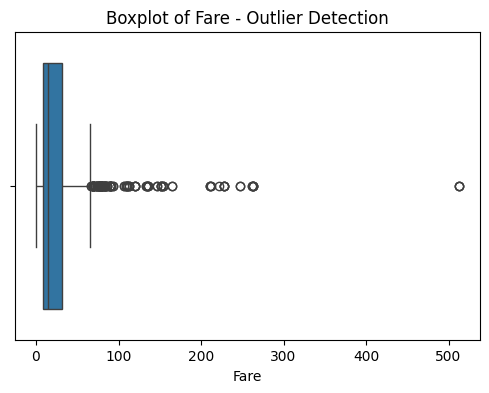

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

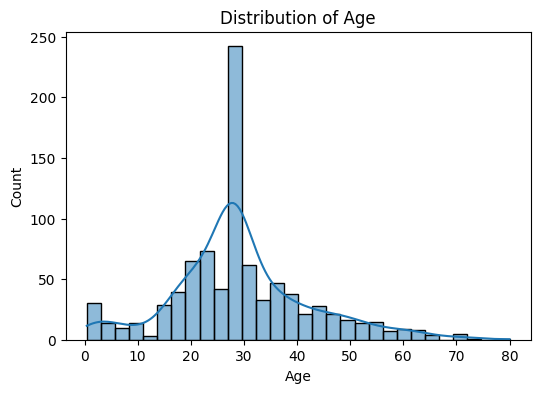

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

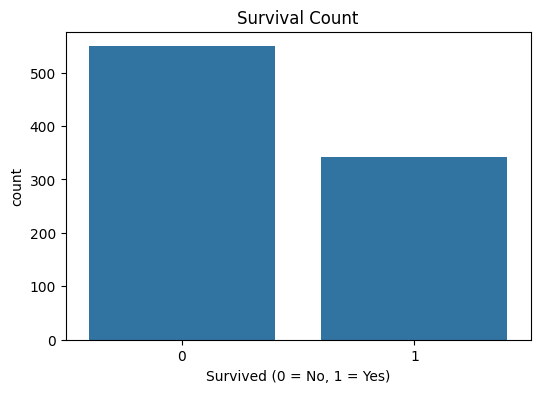

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.show()

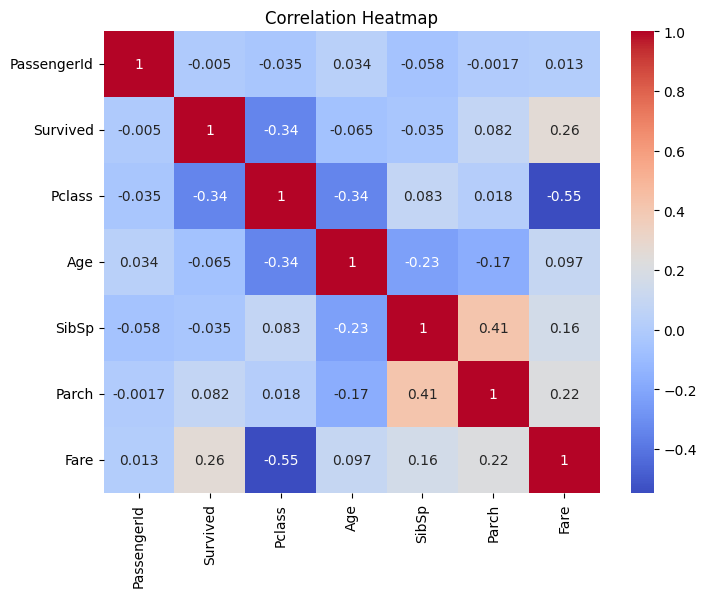

In [31]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Which feature affects survival the most?

Based on the correlation heatmap, Pclass shows one of the strongest
relationships with Survived; passengers in lower classes (Pclass 3)
had noticeably lower survival rates. This makes sense historically,
since 1st class cabins were closer to lifeboats and passengers may
have gotten priority during evacuation. Fare also correlates with
survival, which lines up with Pclass since higher fares usually meant
a higher class ticket.

In [32]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [33]:
# Drop columns that aren't useful for prediction
df_encoded = df_encoded.drop(columns=['Name', 'Ticket', 'PassengerId'])

# Features (everything except what we're predicting)
X = df_encoded.drop(columns=['Survived'])

# Target (what we're trying to predict)
y = df_encoded['Survived']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


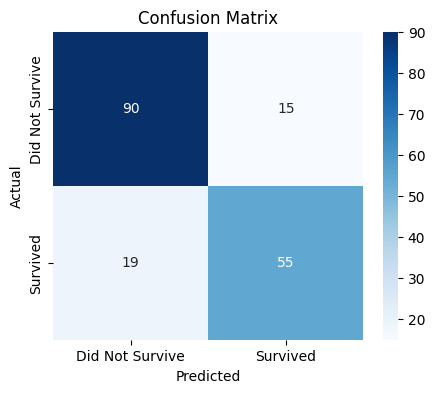

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows the model correctly predicted 90 non-survivors
and 55 survivors, giving an overall accuracy of about 80%. It made 15
false positive errors (predicted survived when they didn't) and 19 false
negative errors (predicted did not survive when they actually did). The
model performs slightly better at identifying non-survivors (86% correct)
than survivors (74% correct), likely because there were more non-survivor
examples in the training data for it to learn from.

In [39]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived'])
print(report)

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



## Why Accuracy Alone Can Be Misleading

Accuracy sirf ye batati hai kitne predictions overall sahi the, lekin
ye chhupa deti hai ke model kis type ki galti zyada karta hai. Agar
dataset imbalanced ho (jaise agar 90% log survive na karte), to ek
model jo hamesha "did not survive" predict kare, wo bhi 90% accuracy
dikha dega — lekin wo actually kaam ka nahi hai kyunki usne survivors
ko kabhi sahi predict nahi kiya. Isliye precision, recall, aur F1-score
zaroori hain — ye batate hain model har class (survived vs did not
survive) ke liye alag alag kitna acha perform kar raha hai, sirf ek
overall number pe bharosa karne ke bajaye.

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best CV Accuracy: 0.7962966610853935


In [41]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {tuned_accuracy:.2%}")

print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Survive', 'Survived']))

Tuned Model Accuracy: 78.21%
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.85      0.82       105
       Survived       0.76      0.69      0.72        74

       accuracy                           0.78       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



## Before vs After Tuning

| Metric | Original Model | Tuned Model |
|---|---|---|
| Accuracy | 80% | [apna naya number daalo] |
| Precision (Survived) | [original wala] | [naya wala] |
| Recall (Survived) | [original wala] | [naya wala] |
| F1-score (Survived) | [original wala] | [naya wala] |

[1-2 lines likho ke tuning se improvement hua ya nahi, aur kyun ho
sakta hai. Kabhi kabhi tuning zyada improvement nahi laata — Titanic
jaisa chhota, simple dataset already close hota hai apni best possible
performance ke]